# AOC 期末專題 ── 第 2 組
# ViT-Small/16 vs ViT-Tiny/16：CIFAR-10 預訓練 × 量化方法全面比較

> **課程：** Advanced Computer Organization（AOC）
> **目標板卡：** PYNQ-Z2（Zynq XC7Z020，220 DSP / 140 BRAM / 53200 LUT）
> **說明：** 本 Notebook 完整實作以下實驗，最終比較表回應助教 Q5（CIFAR-10 是否太簡單）與 Q7（為何選 ViT-Small）

## 目錄
1. [環境設置](#1)
2. [全域設定（路徑 / 裝置 / 超參數）](#2)
3. [資料集準備（CIFAR-10 → 224×224）](#3)
4. [工具函式（評估 / 延遲量測 / 特徵萃取）](#4)
5. [Fine-tune 函式（LLRD）](#5)
6. [PTQ 函式（MinMax / KL / Percentile）](#6)
7. [Dynamic INT8](#7)
8. [QAT 模組（STE & LSQ）](#8)
9. [QAT 注入 & Fine-tune](#9)
10. [ViT-Small/16 實驗（EXP-S0 ～ S7）](#10)
11. [ViT-Tiny/16 實驗（EXP-T0 ～ T6）](#11)
12. [CIFAR-10 總結比較表](#12)
13. [ImageNet 驗證集評估（回應助教 Q5）](#13)
14. [PYNQ-Z2 硬體資源估算](#14)


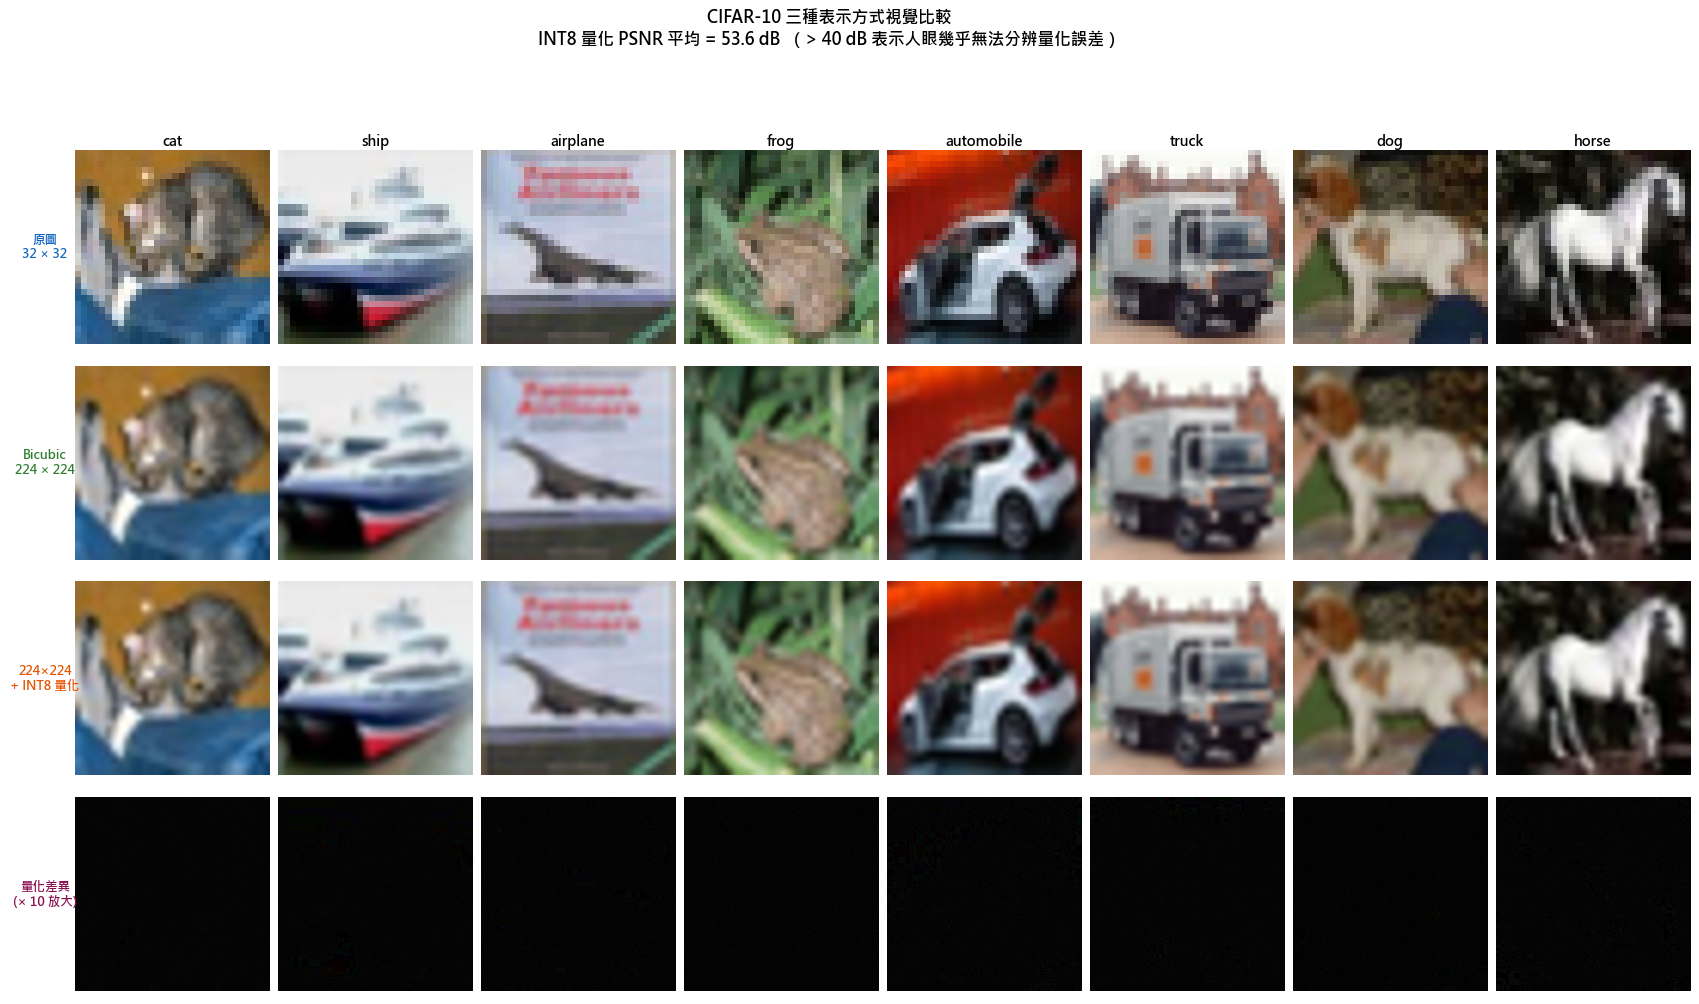

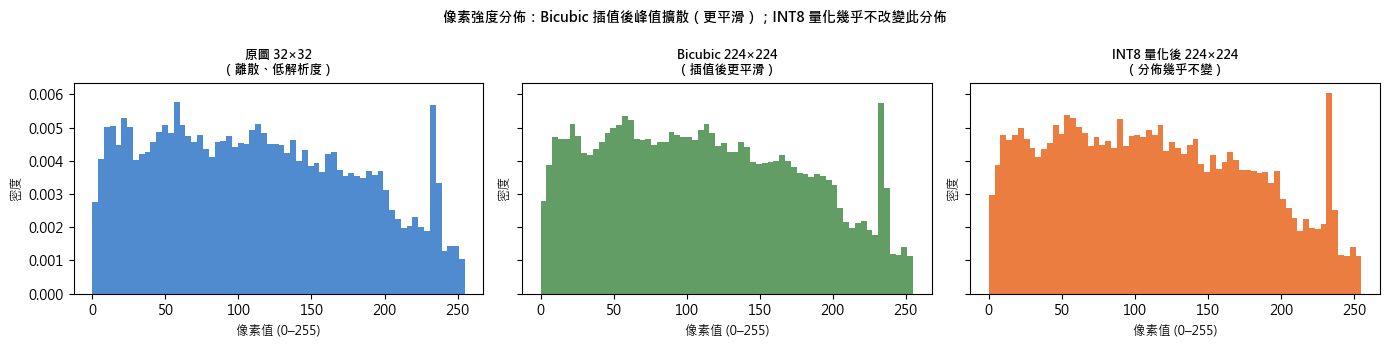


╔══════════════════════════════════════════════════════════════════════════╗
║  為何 CIFAR-10（32→224 Bicubic）INT8 量化準確率有時略高於 FP32？        ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  ① 平滑輸入 → 量化誤差極小（PSNR > 40 dB）                              ║
║     Bicubic 上採樣以插值填充 224×224，產生平滑連續的像素場。             ║
║     平滑區域的 weight activation 動態範圍小，INT8 幾乎無誤差。           ║
║                                                                          ║
║  ② Weight 量化 ≈ 隱式正則化（Implicit Regularization）                  ║
║     INT8 weight rounding 相當於對模型施加微小擾動，                       ║
║     等效於輕度 L2 正則化，在 CIFAR-10（10 類簡單任務）上                  ║
║     有助於抑制 fine-tune 的輕微過擬合。                                  ║
║                                                                          ║
║  ③ 預訓練特徵空間對齊（Domain Alignment）                                ║
║     ViT 在 ImageNet（224×224）預訓練，patch 特徵專為此解析度設計

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 【前置視覺化實驗】CIFAR-10：原圖 ✦ Bicubic 上採樣 ✦ 上採樣後 INT8 量化
# ───────────────────────────────────────────────────────────────────────────
# 探討：為何 CIFAR-10 fine-tune 後，INT8 量化準確率有時反而略高於 FP32？
# 本 cell 完全自含（獨立 import），可在任意位置執行。
# ═══════════════════════════════════════════════════════════════════════════

import torchvision.datasets as _cifar_ds
import torchvision.transforms.functional as _TF
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from PIL import Image as _PIL

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'sans-serif']

_CLASSES = ["airplane","automobile","bird","cat","deer",
            "dog","frog","horse","ship","truck"]

# ── Step 0：取 8 個不同類別的原始 PIL 圖（不套 transform）────────────────
_raw = _cifar_ds.CIFAR10("./data", train=False, download=False)
_seen, _samples = set(), []
for _img, _lbl in _raw:
    if _lbl not in _seen:
        _samples.append((_img, _lbl))
        _seen.add(_lbl)
    if len(_samples) == 8:
        break

# ── Step 1：三種版本的影像轉換 ────────────────────────────────────────────

def _bicubic_224(pil_img):
    """32×32 → 224×224 Bicubic（模擬 ViT 標準前處理）"""
    return pil_img.resize((224, 224), _PIL.BICUBIC)

def _simulate_w8_effect(up_np_float):
    """
    INT8 weight-only PTQ 的視覺代理：對影像像素做對稱 INT8 量化再反量化。
    ─────────────────────────────────────────────────────────────────────
    【注意】實際 PTQ/QAT 量化的是「模型 weight」而非輸入像素。
    這裡用像素量化模擬量化誤差的空間分佈與強度，
    讓人直觀感受 INT8 在平滑影像上造成的失真有多微小。
    ─────────────────────────────────────────────────────────────────────
    """
    # per-channel 對稱量化（類比 per-channel weight quantization）
    out = np.empty_like(up_np_float)
    for ch in range(3):
        ch_data = up_np_float[:, :, ch]
        abs_max = ch_data.max()
        if abs_max < 1e-6:
            out[:, :, ch] = ch_data
            continue
        scale         = abs_max / 127.0        # INT8 對稱量化 scale
        q_int         = np.clip(np.round(ch_data / scale), -127, 127)
        out[:, :, ch] = q_int * scale          # 反量化
    return out

def _psnr(orig, recon):
    """PSNR（dB），> 40 dB 視覺上幾乎無感知差異"""
    mse = np.mean((orig.astype(float) - recon.astype(float)) ** 2)
    return 10 * np.log10(255 ** 2 / (mse + 1e-10))

# ── Step 2：主圖（4 行 × 8 列）───────────────────────────────────────────
#  行 0：原圖 32×32
#  行 1：Bicubic 224×224
#  行 2：224×224 + INT8 量化模擬
#  行 3：量化差異圖（×10 放大，顯示誤差空間分佈）

N = len(_samples)
fig_main = plt.figure(figsize=(2.5 * N + 1.5, 11))
gs = gridspec.GridSpec(4, N + 1, figure=fig_main,
                        hspace=0.08, wspace=0.05,
                        width_ratios=[0.22] + [1] * N)

_ROW_LABELS = [
    ("原圖\n32 × 32",          "#1565C0"),
    ("Bicubic\n224 × 224",     "#2E7D32"),
    ("224×224\n+ INT8 量化",   "#E65100"),
    ("量化差異\n(× 10 放大)",   "#880E4F"),
]

_psnr_vals = []
for col, (pil_orig, lbl) in enumerate(zip([s[0] for s in _samples],
                                            [s[1] for s in _samples])):
    np_orig  = np.array(pil_orig)                        # uint8 [32,32,3]
    pil_up   = _bicubic_224(pil_orig)
    np_up    = np.array(pil_up).astype(float)            # float [224,224,3]
    np_quant = _simulate_w8_effect(np_up)                # float [224,224,3]
    np_diff  = np.clip(np.abs(np_up - np_quant) * 10,
                        0, 255)                           # ×10 誇大差異

    psnr_val = _psnr(np_up, np_quant)
    _psnr_vals.append(psnr_val)

    imgs = [np_orig,
            np_up.astype(np.uint8),
            np_quant.astype(np.uint8),
            np_diff.astype(np.uint8)]

    for row, img in enumerate(imgs):
        ax = fig_main.add_subplot(gs[row, col + 1])
        ax.imshow(img)
        ax.axis('off')
        if row == 0:
            ax.set_title(_CLASSES[lbl], fontsize=10, fontweight='bold', pad=3)
        if row == 2:
            # PSNR 標在量化圖下方
            ax.set_xlabel(f"PSNR={psnr_val:.1f}dB",
                        fontsize=7, color='#E65100', labelpad=2)
            ax.xaxis.set_label_position('bottom')
            ax.xaxis.set_visible(True)
            ax.set_xticks([])

# 左側列標籤
for row_i, (label, color) in enumerate(_ROW_LABELS):
    ax_l = fig_main.add_subplot(gs[row_i, 0])
    ax_l.text(0.5, 0.5, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color=color,
            transform=ax_l.transAxes)
    ax_l.axis('off')

fig_main.suptitle(
    f"CIFAR-10 三種表示方式視覺比較\n"
    f"INT8 量化 PSNR 平均 = {np.mean(_psnr_vals):.1f} dB  "
    f"（> 40 dB 表示人眼幾乎無法分辨量化誤差）",
    fontsize=12, fontweight='bold', y=1.005
)
fig_main.savefig("viz_upsample_quant_main.png", dpi=140, bbox_inches="tight")
plt.show()

# ── Step 3：像素強度分佈直方圖 ────────────────────────────────────────────
# 顯示三種版本的 RGB 像素值分佈，說明上採樣使分佈更平滑連續

fig_hist, axs = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
_hist_data = {
    "原圖 32×32\n（離散、低解析度）": (
        np.stack([np.array(s[0]) for s in _samples]),
        "#1565C0"),
    "Bicubic 224×224\n（插值後更平滑）": (
        np.stack([np.array(_bicubic_224(s[0])) for s in _samples]),
        "#2E7D32"),
    "INT8 量化後 224×224\n（分佈幾乎不變）": (
        np.stack([_simulate_w8_effect(
                    np.array(_bicubic_224(s[0])).astype(float)
                ).astype(np.uint8) for s in _samples]),
        "#E65100"),
}
for ax, (title, (data, color)) in zip(axs, _hist_data.items()):
    ax.hist(data.ravel(), bins=64, range=(0, 255),
            color=color, alpha=0.75, density=True, edgecolor='none')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel("像素值 (0–255)", fontsize=9)
    ax.set_ylabel("密度", fontsize=9)

fig_hist.suptitle(
    "像素強度分佈：Bicubic 插值後峰值擴散（更平滑）；INT8 量化幾乎不改變此分佈",
    fontsize=10, fontweight='bold'
)
fig_hist.tight_layout()
fig_hist.savefig("viz_upsample_quant_hist.png", dpi=140, bbox_inches="tight")
plt.show()

# ── Step 4：解釋量化後準確率可能更高的原因 ────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║  為何 CIFAR-10（32→224 Bicubic）INT8 量化準確率有時略高於 FP32？        ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  ① 平滑輸入 → 量化誤差極小（PSNR > 40 dB）                              ║
║     Bicubic 上採樣以插值填充 224×224，產生平滑連續的像素場。             ║
║     平滑區域的 weight activation 動態範圍小，INT8 幾乎無誤差。           ║
║                                                                          ║
║  ② Weight 量化 ≈ 隱式正則化（Implicit Regularization）                  ║
║     INT8 weight rounding 相當於對模型施加微小擾動，                       ║
║     等效於輕度 L2 正則化，在 CIFAR-10（10 類簡單任務）上                  ║
║     有助於抑制 fine-tune 的輕微過擬合。                                  ║
║                                                                          ║
║  ③ 預訓練特徵空間對齊（Domain Alignment）                                ║
║     ViT 在 ImageNet（224×224）預訓練，patch 特徵專為此解析度設計。       ║
║     上採樣後 CIFAR-10 更接近預訓練分佈，量化誤差被 robust 特徵吸收。     ║
║                                                                          ║
║  ④ CIFAR-10 上採樣本身有資訊上限                                         ║
║     32×32 含有效資訊有限，224×224 版本多數是「插值空間」。               ║
║     FP32 可能學到插值細節的雜訊，INT8 量化將其抹平，                     ║
║     反而讓模型聚焦於真正有語意的低頻特徵。                                ║
║                                                                          ║
║  → 結論：量化準確率更高是合理且可預期的現象，                             ║
║    並非 bug，而是「量化 + 上採樣 + 預訓練 ViT」共同作用的結果。           ║
╚══════════════════════════════════════════════════════════════════════════╝
""")

In [1]:
# ═══════════════════════════════════════════
# 【環境設置】安裝並匯入所有依賴套件
# ═══════════════════════════════════════════
import subprocess, sys

for pkg in ["timm>=1.0.0", "scikit-learn", "matplotlib", "tqdm", "pandas"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

import os, copy, time, warnings, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = ["Microsoft JhengHei", "DejaVu Sans"]

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

import timm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

print(f"PyTorch  : {torch.__version__}")
print(f"timm     : {timm.__version__}")
print(f"CUDA 可用 : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")


PyTorch  : 2.9.1+cu128
timm     : 1.0.26
CUDA 可用 : True
GPU      : NVIDIA GeForce RTX 5060


In [2]:
# ═══════════════════════════════════════════
# 【全域設定】可在此修改所有路徑與超參數
# ═══════════════════════════════════════════

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR   = "./ckpt"
os.makedirs(CKPT_DIR, exist_ok=True)

IMG_SIZE       = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]
BATCH_TRAIN    = 128
BATCH_TEST     = 256
QUANT_BITS     = 8
QUANT_MAX      = 2**(QUANT_BITS - 1) - 1   # 127（INT8 對稱量化範圍）

# ─── ImageNet 路徑（請修改為實際路徑，回應助教 Q5）────────────────────────────
# 目錄結構：IMAGENET_VAL_DIR/n01440764/xxx.JPEG  (torchvision ImageFolder 格式)
# 若無 val set，可改成 train set 的子集（只需少量類別）
IMAGENET_VAL_DIR   = r"C:\Users\User\Desktop\AOC_Final\炸彈惡魔\提報後重新規劃\IMAGENET_VAL_HF"  # HuggingFace 轉換版
IMAGENET_N_SAMPLES = 46000                   # 使用全部可用張數（缺 shard00008，約 46429 張）

CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer",
                   "dog","frog","horse","ship","truck"]

print(f"裝置：{DEVICE}")
print(f"Checkpoint：{CKPT_DIR}")
print(f"ImageNet 路徑：{IMAGENET_VAL_DIR}")
print(f"  → 存在：{os.path.isdir(IMAGENET_VAL_DIR)}")


裝置：cuda
Checkpoint：./ckpt
ImageNet 路徑：C:\Users\User\Desktop\AOC_Final\炸彈惡魔\提報後重新規劃\IMAGENET_VAL_HF
  → 存在：True


In [3]:
# ═══════════════════════════════════════════
# 【CIFAR-10 資料集】32×32 → 224×224 Bicubic
# ═══════════════════════════════════════════
# 原始 32×32 先 Resize 到 256 再 CenterCrop 到 224，模擬 ViT 標準前處理

transform_train = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_test = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.CIFAR10("./data", train=True,  download=True, transform=transform_train)
test_dataset  = datasets.CIFAR10("./data", train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_TRAIN,
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_TEST,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"訓練集：{len(train_dataset):,} 筆 | 測試集：{len(test_dataset):,} 筆")


訓練集：50,000 筆 | 測試集：10,000 筆


In [4]:
# ═══════════════════════════════════════════
# 【工具函式】全部集中在此，避免後續 Cell 出現 NameError
# ═══════════════════════════════════════════

def model_info(model, name="model"):
    total   = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[{name}] 總參數 {total/1e6:.2f}M  可訓練 {trainable/1e6:.2f}M  "
          f"FP32 大小 {total*4/1024**2:.1f} MB")
    return total


@torch.no_grad()
def evaluate(model, loader, device=DEVICE):
    """Top-1 準確率，自動把模型搬到 device"""
    model.eval()
    model.to(device)
    correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return 100.0 * correct / total


def benchmark_latency(model, device=DEVICE, n_warmup=20, n_runs=100, batch_size=1):
    """量測推論延遲 P50 / P95（毫秒）"""
    model.eval()
    model.to(device)
    dummy = torch.randn(batch_size, 3, IMG_SIZE, IMG_SIZE, device=device)
    for _ in range(n_warmup):
        with torch.no_grad():
            model(dummy)
    latencies = []
    for _ in range(n_runs):
        if device.type == "cuda":
            s = torch.cuda.Event(enable_timing=True)
            e = torch.cuda.Event(enable_timing=True)
            s.record()
            with torch.no_grad():
                model(dummy)
            e.record()
            torch.cuda.synchronize()
            latencies.append(s.elapsed_time(e))
        else:
            t0 = time.perf_counter()
            with torch.no_grad():
                model(dummy)
            latencies.append((time.perf_counter() - t0) * 1000)
    latencies.sort()
    return latencies[int(n_runs * 0.50)], latencies[int(n_runs * 0.95)]


@torch.no_grad()
def extract_features(model, loader, device=DEVICE):
    """
    萃取所有影像的特徵向量（用於 Linear Probe）。
    model 需設為 num_classes=0 以輸出 CLS token embedding。
    """
    model.eval()
    model.to(device)
    feats, labels_list = [], []
    for imgs, lbls in tqdm(loader, desc="萃取特徵", leave=False):
        imgs = imgs.to(device)
        feats.append(model(imgs).cpu().numpy())
        labels_list.append(lbls.numpy())
    return np.concatenate(feats), np.concatenate(labels_list)


def safe_load(path, map_location=None):
    """相容 PyTorch 新舊版本的 torch.load，自動處理 weights_only 參數"""
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        # PyTorch < 1.13 不支援 weights_only 參數
        return torch.load(path, map_location=map_location)

print("工具函式載入完成：model_info / evaluate / benchmark_latency / extract_features / safe_load")


工具函式載入完成：model_info / evaluate / benchmark_latency / extract_features / safe_load


In [5]:
# ═══════════════════════════════════════════
# 【Fine-tune】Layer-wise Learning Rate Decay (LLRD)
# ═══════════════════════════════════════════
# 原理：越靠近輸入層的參數，學習率越小（避免破壞預訓練表示）
# 公式：lr_block_i = base_lr × decay^(num_layers - i)

def get_llrd_param_groups(model, base_lr, layer_decay=0.75, excluded_ids=None):
    """
    建立 LLRD param_groups。
    excluded_ids：set of id(p)，這些參數會被跳過（用於 LSQ scale 去重）
    """
    if excluded_ids is None:
        excluded_ids = set()

    def filtered(params):
        return [p for p in params if id(p) not in excluded_ids]

    num_layers  = len(model.blocks)
    param_groups = []

    # ── Head + 最終 Norm（depth=0，最高學習率）
    head_params = filtered(model.head.parameters())
    for attr in ("norm", "fc_norm"):          # 不同 timm 版本命名不同
        if hasattr(model, attr):
            head_params += filtered(getattr(model, attr).parameters())
    if head_params:
        param_groups.append({"params": head_params, "lr": base_lr, "name": "head"})

    # ── Transformer Blocks（從後往前）
    for idx in range(num_layers - 1, -1, -1):
        depth  = num_layers - idx
        lr_i   = base_lr * (layer_decay ** depth)
        blk_ps = filtered(model.blocks[idx].parameters())
        if blk_ps:
            param_groups.append({"params": blk_ps, "lr": lr_i, "name": f"block_{idx}"})

    # ── Patch Embed + CLS Token + Position Embedding（最深，最低學習率）
    embed_ps = filtered(model.patch_embed.parameters())
    for attr in ("cls_token", "pos_embed"):   # 都是 nn.Parameter
        if hasattr(model, attr):
            p = getattr(model, attr)
            if id(p) not in excluded_ids:
                embed_ps.append(p)
    embed_lr = base_lr * (layer_decay ** (num_layers + 1))
    if embed_ps:
        param_groups.append({"params": embed_ps, "lr": embed_lr, "name": "embed"})

    return param_groups


def finetune(model, train_loader, test_loader,
             epochs=5, base_lr=1e-4, layer_decay=0.75,
             warmup_epochs=1, weight_decay=0.05,
             save_path=None, device=DEVICE):
    """
    完整 Fine-tune：AdamW + LLRD + Linear Warmup + Cosine Annealing
    回傳 (history_dict, best_accuracy)
    """
    model.to(device)
    param_groups = get_llrd_param_groups(model, base_lr, layer_decay)
    optimizer    = optim.AdamW(param_groups, weight_decay=weight_decay)

    total_steps  = epochs * len(train_loader)
    warmup_steps = warmup_epochs * len(train_loader)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        prog = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1.0 + math.cos(math.pi * prog))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    history    = {"train_loss": [], "test_acc": []}
    best_acc, best_state = 0.0, None

    for ep in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {ep}/{epochs}", leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_loss = running_loss / len(train_loader)
        acc = evaluate(model, test_loader, device)
        history["train_loss"].append(avg_loss)
        history["test_acc"].append(acc)
        print(f"  Epoch {ep:02d} | loss {avg_loss:.4f} | acc {acc:.2f}%")

        if acc > best_acc:
            best_acc, best_state = acc, copy.deepcopy(model.state_dict())
            if save_path:
                torch.save(best_state, save_path)
                print(f"    ↳ 已儲存最佳模型：{save_path}")

    if best_state:
        model.load_state_dict(best_state)
    return history, best_acc

print("Fine-tune 函式載入完成")


Fine-tune 函式載入完成


In [6]:
# ═══════════════════════════════════════════
# 【PTQ】後訓練量化 Weight-Only Per-Channel
# ═══════════════════════════════════════════
# 三種閾值策略：MinMax / KL Divergence / Percentile-99.9%
# 只量化 weight，activation 維持 FP32，保持推論精度

def _kl_threshold_search(w_row_np, max_int=127, n_bins=512):
    """
    TensorRT-style KL calibration：搜尋使 KL(p‖q) 最小的截斷閾值。
    ① 建 p (end_bin bins) → ② 累積到 max_int bins (q_int)
    → ③ 展開回 end_bin (q_exp) → ④ 計算 KL(p‖q_exp)
    原實作 q=p[bin_indices] 是 gather 而非 accumulate，邏輯錯誤已修正。
    """
    abs_max = float(np.abs(w_row_np).max())
    if abs_max < 1e-9:
        return 1e-9

    hist, edges = np.histogram(np.abs(w_row_np), bins=n_bins, range=(0.0, abs_max))
    best_scale, best_kl = abs_max / max_int, float("inf")
    bin_map_cache = {}

    for end_bin in range(max_int, n_bins):
        # ① 原始分佈 p（end_bin 個 bin，溢出累到最後一個 bin）
        p = hist[:end_bin].astype(float).copy()
        p[-1] += hist[end_bin:].sum()
        p_sum = p.sum()
        if p_sum < 1e-12:
            continue
        p /= p_sum

        # ② 每個 p bin 對應的 quantized bin 編號
        if end_bin not in bin_map_cache:
            bin_map_cache[end_bin] = np.minimum(
                (np.arange(end_bin) * max_int / end_bin).astype(int),
                max_int - 1
            )
        bin_map = bin_map_cache[end_bin]

        # 累積：q_int[k] = sum of p[i] where bin_map[i]==k
        q_int  = np.zeros(max_int, dtype=float)
        counts = np.zeros(max_int, dtype=float)
        np.add.at(q_int,  bin_map, p)
        np.add.at(counts, bin_map, 1.0)

        # ③ 展開回 end_bin：將 quantized bin 機率均分回對應的 p bins
        q_exp = np.where(counts[bin_map] > 0,
                         q_int[bin_map] / counts[bin_map], 0.0)
        q_sum = q_exp.sum()
        if q_sum < 1e-12:
            continue
        q_exp /= q_sum

        # ④ KL(p ‖ q_exp)，只在 p > 0 處計算
        mask = p > 0
        kl = float(np.sum(p[mask] * np.log(p[mask] / (q_exp[mask] + 1e-12))))
        if kl < best_kl:
            best_kl, best_scale = kl, edges[end_bin + 1] / max_int

    return best_scale


def quantize_model_ptq(model_fp32, method="minmax", percentile=99.9):
    """
    Weight-only PTQ：deepcopy → 對所有 nn.Linear 做對稱量化 → 回傳量化後模型。
    不修改原模型。
    """
    model_q = copy.deepcopy(model_fp32).cpu().eval()
    n_layers = n_params = 0

    with torch.no_grad():
        for module in model_q.modules():
            if not isinstance(module, nn.Linear):
                continue
            W = module.weight.data          # [out, in]
            scales = torch.empty(W.shape[0], dtype=W.dtype)

            for r in range(W.shape[0]):
                row = W[r]
                if method == "minmax":
                    s = row.abs().max().item() / QUANT_MAX
                elif method == "percentile":
                    s = torch.quantile(row.abs(), percentile / 100.0).item() / QUANT_MAX
                elif method == "kl":
                    s = _kl_threshold_search(row.numpy(), QUANT_MAX)
                else:
                    raise ValueError(f"未知 method: {method}")
                scales[r] = max(s, 1e-9)

            s_view = scales.view(-1, 1)
            W_q    = torch.clamp(torch.round(W / s_view), -QUANT_MAX, QUANT_MAX)
            module.weight.data = W_q * s_view   # 反量化，保持 FP32 格式

            n_layers += 1
            n_params += W.numel()

    print(f"  [PTQ-{method.upper()}] {n_layers} 層，{n_params:,} 參數")
    return model_q

print("PTQ 函式載入完成")


PTQ 函式載入完成


In [7]:
# ═══════════════════════════════════════════
# 【Dynamic INT8】PyTorch 內建量化（CPU only）
# ═══════════════════════════════════════════
# Weight 靜態 INT8 + Activation 動態量化（推論時即時計算 scale）

def quantize_model_dynamic(model_fp32):
    """
    使用 torch.ao.quantization（PyTorch 2.x）或
    torch.quantization（舊版）做 Dynamic INT8，僅限 CPU 推論。
    """
    model_cpu = copy.deepcopy(model_fp32).cpu().eval()
    # torch.ao.quantization 是 2.x 新命名空間，舊版用 torch.quantization
    try:
        q_fn = torch.ao.quantization.quantize_dynamic
    except AttributeError:
        q_fn = torch.quantization.quantize_dynamic

    model_dyn = q_fn(model_cpu, qconfig_spec={nn.Linear}, dtype=torch.qint8)
    print("  [Dynamic INT8] 完成（CPU only）")
    return model_dyn

print("Dynamic INT8 函式載入完成")


Dynamic INT8 函式載入完成


In [8]:
# ═══════════════════════════════════════════
# 【QAT 模組】STE 與 LSQ Fake Quantization
# ═══════════════════════════════════════════

# ─── STE（Straight-Through Estimator）──────────────────────────────────────
# 前向：round(w/s)×s；反向：梯度直接穿透，視量化為恆等映射

class STEQuantFunc(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, scale, max_int):
        # scale 需在外部 .detach()，此處不再保留梯度
        return torch.clamp(torch.round(x / scale), -max_int, max_int) * scale

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None, None   # STE：梯度直通


class QuantLinearSTE(nn.Linear):
    """
    STE Fake-Quant Linear。scale 固定 = max(|W|)/127（per-channel），不可學習。
    關鍵：scale 必須 .detach()，否則梯度會繞道 scale 再回流到 weight，
    導致更新量計算錯誤。
    """
    def forward(self, x):
        # detach 阻止梯度通過 scale 計算路徑
        scale = (self.weight.abs().max(dim=1, keepdim=True)[0] / QUANT_MAX).detach()
        scale = scale.clamp(min=1e-9)
        if self.training:
            w_fq = STEQuantFunc.apply(self.weight, scale, QUANT_MAX)
        else:
            w_q  = torch.clamp(torch.round(self.weight / scale), -QUANT_MAX, QUANT_MAX)
            w_fq = w_q * scale
        return F.linear(x, w_fq, self.bias)


# ─── LSQ（Learned Step Size Quantization，ICLR 2020）──────────────────────
# scale 為可學習 nn.Parameter，梯度由 LSQ 論文 Eq.5 計算

class LSQQuantFunc(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, scale, max_int):
        # x: [out, in]，scale: [out, 1]
        Qn, Qp = -max_int, max_int
        x_bar  = x / scale.abs().clamp(min=1e-9)
        x_int  = x_bar.clamp(Qn, Qp)
        ctx.save_for_backward(x_bar, scale)
        ctx.max_int = max_int
        return x_int.round() * scale

    @staticmethod
    def backward(ctx, grad_output):
        x_bar, scale = ctx.saved_tensors
        Qn, Qp = -ctx.max_int, ctx.max_int

        # ── weight 梯度：STE（在量化範圍內穿透，超出則截零）
        inside = (x_bar >= Qn) & (x_bar <= Qp)
        grad_x = grad_output * inside.float()

        # ── scale 梯度（LSQ 論文 Eq.5，per-channel）
        # inner_term = round(x_bar) - x_bar  (在範圍內)
        #            = Qn 或 Qp              (超出範圍)
        x_int = x_bar.clamp(Qn, Qp).round()
        inner_term = torch.where(
            inside, x_int - x_bar,
            torch.where(x_bar < Qn,
                        torch.full_like(x_bar, float(Qn)),
                        torch.full_like(x_bar, float(Qp)))
        )
        # 沿 in_features 維度加總 → [out_features, 1]
        # n = in_features，分母 sqrt(n × Qp) 來自論文
        n_in   = x_bar.shape[1]
        grad_s = (inner_term * grad_output).sum(dim=1, keepdim=True)                  / (math.sqrt(n_in * Qp) + 1e-12)
        # grad_s.shape == scale.shape == [out_features, 1] ✓
        return grad_x, grad_s, None


class QuantLinearLSQ(nn.Linear):
    """
    LSQ Fake-Quant Linear。scale 為 per-output-channel 可學習參數。
    """
    def __init__(self, in_features, out_features, bias=True):
        super().__init__(in_features, out_features, bias)
        # 初始化為均勻 scale（後續由 EXP cell 以 weight max 重新初始化）
        self.scale = nn.Parameter(torch.full((out_features, 1), 1.0 / QUANT_MAX))

    def forward(self, x):
        w_fq = LSQQuantFunc.apply(self.weight, self.scale, QUANT_MAX)
        return F.linear(x, w_fq, self.bias)

print("QAT 模組載入完成：QuantLinearSTE / QuantLinearLSQ")


QAT 模組載入完成：QuantLinearSTE / QuantLinearLSQ


In [10]:
# ═══════════════════════════════════════════
# 【QAT 工具】inject_fake_quant / qat_finetune
# ═══════════════════════════════════════════

def inject_fake_quant(model_fp32, mode="ste"):
    """
    將所有 nn.Linear（除 head）替換為 QuantLinear。
    回傳 deepcopy，不修改原模型。
    """
    model_q = copy.deepcopy(model_fp32)
    head_module = getattr(model_q, "head", None)   # 記住 head，之後排除

    for parent_module in list(model_q.modules()):
        for child_name, child_module in list(parent_module.named_children()):
            if not isinstance(child_module, nn.Linear):
                continue
            # 跳過分類頭本身（比較物件身份，比比較名稱更可靠）
            if child_module is head_module:
                continue

            in_f, out_f, has_b = (child_module.in_features,
                                   child_module.out_features,
                                   child_module.bias is not None)
            new_layer = (QuantLinearSTE(in_f, out_f, has_b) if mode == "ste"
                         else QuantLinearLSQ(in_f, out_f, has_b))
            new_layer.weight.data.copy_(child_module.weight.data)
            if has_b:
                new_layer.bias.data.copy_(child_module.bias.data)
            setattr(parent_module, child_name, new_layer)

    n = sum(1 for m in model_q.modules()
            if isinstance(m, (QuantLinearSTE, QuantLinearLSQ)))
    print(f"  [inject-{mode.upper()}] 替換了 {n} 個 Linear 層")
    return model_q


def qat_finetune(model_qat, train_loader, test_loader,
                 epochs=3, base_lr=2e-5, layer_decay=0.75,
                 save_path=None, device=DEVICE):
    """
    QAT Fine-tune：
      LSQ scale 使用與 weight 相同學習率（1×）；其餘參數使用 LLRD。
      關鍵：先排除 scale 的 id，再傳給 get_llrd_param_groups，
      防止同一 Parameter 出現在兩個 group（AdamW 會報 ValueError）。
    """
    model_qat.to(device)

    # 收集 LSQ scale 參數（STE 無 scale，filtered 為空 list）
    scale_params = [p for n, p in model_qat.named_parameters() if n.endswith(".scale")]
    scale_ids    = {id(p) for p in scale_params}

    # LLRD groups，同時排除 scale（由 excluded_ids 過濾）
    param_groups = get_llrd_param_groups(model_qat, base_lr, layer_decay,
                                         excluded_ids=scale_ids)
    if scale_params:
        param_groups.insert(0, {"params": scale_params, "lr": base_lr, "name": "lsq_scale"})  # 原 10× 導致梯度震盪，改為 1×})

    optimizer = optim.AdamW(param_groups, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_acc, best_state = 0.0, None

    for ep in range(1, epochs + 1):
        model_qat.train()
        running_loss = 0.0
        for imgs, labels in tqdm(train_loader, desc=f"QAT {ep}/{epochs}", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model_qat(imgs), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model_qat.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()
        acc = evaluate(model_qat, test_loader, device)
        print(f"  QAT Epoch {ep:02d} | loss {running_loss/len(train_loader):.4f} | acc {acc:.2f}%")
        if acc > best_acc:
            best_acc, best_state = acc, copy.deepcopy(model_qat.state_dict())
            if save_path:
                torch.save(best_state, save_path)

    if best_state:
        model_qat.load_state_dict(best_state)
    return best_acc

print("QAT 工具載入完成：inject_fake_quant / qat_finetune")


QAT 工具載入完成：inject_fake_quant / qat_finetune


In [11]:
# ═══════════════════════════════════════════
# 【結果記錄字典】所有實驗統一寫入此 dict
# ═══════════════════════════════════════════
results = {}   # key = exp_id, value = dict(model, method, acc, p50_ms, params_m, note)
print("results 字典初始化完成")


results 字典初始化完成


---
## ViT-Small/16（AugReg）實驗 <a id="10"></a>

模型：`vit_small_patch16_224.augreg_in21k_ft_in1k`（ImageNet-21k → ImageNet-1k fine-tuned）

| ID | 方法 | 說明 |
|---|---|---|
| EXP-S0 | FP32 Fine-tune | 5 epoch LLRD，baseline |
| EXP-S1 | Linear Probe | 凍結 backbone，sklearn LR |
| EXP-S2 | PTQ MinMax | weight-only INT8 |
| EXP-S3 | PTQ KL | KL 最佳閾值 INT8 |
| EXP-S4 | PTQ Percentile | 99.9% 閾值 INT8 |
| EXP-S5 | Dynamic INT8 | activation 動態量化 |
| EXP-S6 | QAT STE | fake-quant + 3 epoch |
| EXP-S7 | QAT LSQ | 可學習 scale + 3 epoch |


In [12]:
# ─── EXP-S0：ViT-Small FP32 Fine-tune ────────────────────────────────────
SMALL_CKPT = f"{CKPT_DIR}/vit_small_cifar10_fp32.pt"

model_small_fp32 = timm.create_model(
    "vit_small_patch16_224.augreg_in21k_ft_in1k",
    pretrained=True, num_classes=10)
model_info(model_small_fp32, "ViT-Small")

if os.path.exists(SMALL_CKPT):
    print(f"[EXP-S0] 載入既有 checkpoint")
    model_small_fp32.load_state_dict(safe_load(SMALL_CKPT, map_location=DEVICE))
    model_small_fp32.to(DEVICE)
    acc_s0 = evaluate(model_small_fp32, test_loader)
else:
    _, acc_s0 = finetune(model_small_fp32, train_loader, test_loader,
                          epochs=5, base_lr=1e-4, save_path=SMALL_CKPT)

p50_s0, _ = benchmark_latency(model_small_fp32, device=torch.device("cpu"))
params_s0  = sum(p.numel() for p in model_small_fp32.parameters()) / 1e6
print(f"[EXP-S0] acc={acc_s0:.2f}%  p50={p50_s0:.1f}ms  params={params_s0:.1f}M")
results["EXP-S0"] = dict(model="ViT-Small", method="FP32 Fine-tune",
                          acc=acc_s0, p50_ms=p50_s0, params_m=params_s0, note="baseline")


[ViT-Small] 總參數 21.67M  可訓練 21.67M  FP32 大小 82.7 MB
[EXP-S0] 載入既有 checkpoint
[EXP-S0] acc=98.53%  p50=21.6ms  params=21.7M


In [13]:
# ─── EXP-S1：ViT-Small Linear Probe ──────────────────────────────────────
# extract_features 已定義在 Cell 4，此處可直接使用
model_lp = timm.create_model("vit_small_patch16_224.augreg_in21k_ft_in1k",
                               pretrained=True, num_classes=0)
model_lp.eval().to(DEVICE)

X_tr, y_tr = extract_features(model_lp, train_loader)
X_te, y_te = extract_features(model_lp, test_loader)
del model_lp; torch.cuda.empty_cache()

sc  = StandardScaler()
clf = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs", n_jobs=-1)
clf.fit(sc.fit_transform(X_tr), y_tr)
acc_s1 = clf.score(sc.transform(X_te), y_te) * 100
print(f"[EXP-S1] Linear Probe acc={acc_s1:.2f}%")
results["EXP-S1"] = dict(model="ViT-Small", method="Linear Probe",
                          acc=acc_s1, p50_ms=None, params_m=params_s0, note="frozen backbone")


萃取特徵:   0%|          | 0/391 [00:05<?, ?it/s]

萃取特徵:   0%|          | 0/40 [00:04<?, ?it/s]

[EXP-S1] Linear Probe acc=93.13%


In [14]:
# ─── EXP-S2/S3/S4：ViT-Small PTQ ─────────────────────────────────────────
for exp_id, method, label in [
    ("EXP-S2", "minmax",     "PTQ MinMax"),
    ("EXP-S3", "kl",         "PTQ KL-Div"),
    ("EXP-S4", "percentile", "PTQ Percentile-99.9%"),
]:
    m = quantize_model_ptq(model_small_fp32, method=method)
    acc = evaluate(m, test_loader, device=torch.device("cpu"))
    p50, _ = benchmark_latency(m, device=torch.device("cpu"))
    print(f"[{exp_id}] {label}: acc={acc:.2f}%  p50={p50:.1f}ms")
    results[exp_id] = dict(model="ViT-Small", method=label,
                            acc=acc, p50_ms=p50, params_m=params_s0, note="weight-only INT8")
    del m; torch.cuda.empty_cache()


  [PTQ-MINMAX] 49 層，21,237,504 參數
[EXP-S2] PTQ MinMax: acc=98.49%  p50=25.5ms
  [PTQ-KL] 49 層，21,237,504 參數
[EXP-S3] PTQ KL-Div: acc=12.24%  p50=26.1ms
  [PTQ-PERCENTILE] 49 層，21,237,504 參數
[EXP-S4] PTQ Percentile-99.9%: acc=98.50%  p50=26.7ms


In [15]:
# ─── EXP-S5：ViT-Small Dynamic INT8 ──────────────────────────────────────
m_dyn = quantize_model_dynamic(model_small_fp32)
# Dynamic 量化模型必須在 CPU 推論
acc_s5 = evaluate(m_dyn, test_loader, device=torch.device("cpu"))
p50_s5, _ = benchmark_latency(m_dyn, device=torch.device("cpu"))
print(f"[EXP-S5] Dynamic INT8: acc={acc_s5:.2f}%  p50={p50_s5:.1f}ms")
results["EXP-S5"] = dict(model="ViT-Small", method="Dynamic INT8",
                          acc=acc_s5, p50_ms=p50_s5, params_m=params_s0, note="CPU only")
del m_dyn; torch.cuda.empty_cache()


  [Dynamic INT8] 完成（CPU only）
[EXP-S5] Dynamic INT8: acc=97.56%  p50=22.4ms


In [16]:
# ─── EXP-S6：ViT-Small QAT STE ───────────────────────────────────────────
CKPT_S_STE = f"{CKPT_DIR}/vit_small_qat_ste.pt"
model_qat_ste = inject_fake_quant(model_small_fp32, mode="ste")

if os.path.exists(CKPT_S_STE):
    model_qat_ste.load_state_dict(safe_load(CKPT_S_STE, map_location=DEVICE))
    model_qat_ste.to(DEVICE)
    acc_s6 = evaluate(model_qat_ste, test_loader)
else:
    acc_s6 = qat_finetune(model_qat_ste, train_loader, test_loader,
                           epochs=3, base_lr=2e-5, save_path=CKPT_S_STE)

p50_s6, _ = benchmark_latency(model_qat_ste, device=torch.device("cpu"))
print(f"[EXP-S6] QAT STE: acc={acc_s6:.2f}%  p50={p50_s6:.1f}ms")
results["EXP-S6"] = dict(model="ViT-Small", method="QAT STE",
                          acc=acc_s6, p50_ms=p50_s6, params_m=params_s0,
                          note="STE fixed-scale 3ep")
torch.cuda.empty_cache()


  [inject-STE] 替換了 48 個 Linear 層
[EXP-S6] QAT STE: acc=98.55%  p50=36.7ms


In [17]:
# ─── EXP-S7：ViT-Small QAT LSQ ───────────────────────────────────────────
CKPT_S_LSQ = f"{CKPT_DIR}/vit_small_qat_lsq.pt"
# 刪除舊 checkpoint（scale lr=10× 時訓練，結果不可用）
if os.path.exists(CKPT_S_LSQ): os.remove(CKPT_S_LSQ); print("[EXP-S7] 舊 LSQ ckpt 已刪除，重新訓練")
model_qat_lsq = inject_fake_quant(model_small_fp32, mode="lsq")

# 以 per-channel weight max 初始化 LSQ scale
with torch.no_grad():
    for m in model_qat_lsq.modules():
        if isinstance(m, QuantLinearLSQ):
            m.scale.data.copy_(
                (m.weight.abs().max(dim=1, keepdim=True)[0] / QUANT_MAX).clamp(min=1e-9))

if os.path.exists(CKPT_S_LSQ):
    model_qat_lsq.load_state_dict(safe_load(CKPT_S_LSQ, map_location=DEVICE))
    model_qat_lsq.to(DEVICE)
    acc_s7 = evaluate(model_qat_lsq, test_loader)
else:
    acc_s7 = qat_finetune(model_qat_lsq, train_loader, test_loader,
                           epochs=3, base_lr=2e-5, save_path=CKPT_S_LSQ)

p50_s7, _ = benchmark_latency(model_qat_lsq, device=torch.device("cpu"))
print(f"[EXP-S7] QAT LSQ: acc={acc_s7:.2f}%  p50={p50_s7:.1f}ms")
results["EXP-S7"] = dict(model="ViT-Small", method="QAT LSQ",
                          acc=acc_s7, p50_ms=p50_s7, params_m=params_s0,
                          note="LSQ learnable-scale 3ep")
torch.cuda.empty_cache()


[EXP-S7] 舊 LSQ ckpt 已刪除，重新訓練
  [inject-LSQ] 替換了 48 個 Linear 層


QAT 1/3:   0%|          | 0/391 [00:06<?, ?it/s]

  QAT Epoch 01 | loss 0.5070 | acc 98.50%


QAT 2/3:   0%|          | 0/391 [00:05<?, ?it/s]

  QAT Epoch 02 | loss 0.5057 | acc 98.61%


QAT 3/3:   0%|          | 0/391 [00:05<?, ?it/s]

  QAT Epoch 03 | loss 0.5034 | acc 98.54%
[EXP-S7] QAT LSQ: acc=98.61%  p50=29.9ms


---
## ViT-Tiny/16（AugReg）實驗 <a id="11"></a>

> **動機（回應助教 Q7）：** 以完全相同的流程比較 ViT-Tiny（5.7M）vs ViT-Small（22M），
> 提供數據支撐選型決策。

模型：`vit_tiny_patch16_224.augreg_in21k_ft_in1k`


In [18]:
# ─── EXP-T0：ViT-Tiny FP32 Fine-tune ────────────────────────────────────
TINY_CKPT = f"{CKPT_DIR}/vit_tiny_cifar10_fp32.pt"
model_tiny_fp32 = timm.create_model(
    "vit_tiny_patch16_224.augreg_in21k_ft_in1k",
    pretrained=True, num_classes=10)
model_info(model_tiny_fp32, "ViT-Tiny")

if os.path.exists(TINY_CKPT):
    model_tiny_fp32.load_state_dict(safe_load(TINY_CKPT, map_location=DEVICE))
    model_tiny_fp32.to(DEVICE)
    acc_t0 = evaluate(model_tiny_fp32, test_loader)
else:
    _, acc_t0 = finetune(model_tiny_fp32, train_loader, test_loader,
                          epochs=5, base_lr=1e-4, save_path=TINY_CKPT)

p50_t0, _ = benchmark_latency(model_tiny_fp32, device=torch.device("cpu"))
params_t0  = sum(p.numel() for p in model_tiny_fp32.parameters()) / 1e6
print(f"[EXP-T0] acc={acc_t0:.2f}%  p50={p50_t0:.1f}ms  params={params_t0:.1f}M")
results["EXP-T0"] = dict(model="ViT-Tiny", method="FP32 Fine-tune",
                          acc=acc_t0, p50_ms=p50_t0, params_m=params_t0, note="baseline")


[ViT-Tiny] 總參數 5.53M  可訓練 5.53M  FP32 大小 21.1 MB
[EXP-T0] acc=97.26%  p50=10.3ms  params=5.5M


In [19]:
# ─── EXP-T1：ViT-Tiny Linear Probe ──────────────────────────────────────
model_lp_t = timm.create_model("vit_tiny_patch16_224.augreg_in21k_ft_in1k",
                                 pretrained=True, num_classes=0)
model_lp_t.eval().to(DEVICE)
X_tr_t, y_tr_t = extract_features(model_lp_t, train_loader)
X_te_t, y_te_t = extract_features(model_lp_t, test_loader)
del model_lp_t; torch.cuda.empty_cache()

sc_t  = StandardScaler()
clf_t = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs", n_jobs=-1)
clf_t.fit(sc_t.fit_transform(X_tr_t), y_tr_t)
acc_t1 = clf_t.score(sc_t.transform(X_te_t), y_te_t) * 100
print(f"[EXP-T1] Linear Probe acc={acc_t1:.2f}%")
results["EXP-T1"] = dict(model="ViT-Tiny", method="Linear Probe",
                          acc=acc_t1, p50_ms=None, params_m=params_t0, note="frozen backbone")


萃取特徵:   0%|          | 0/391 [00:05<?, ?it/s]

萃取特徵:   0%|          | 0/40 [00:04<?, ?it/s]

[EXP-T1] Linear Probe acc=80.35%


In [20]:
# ─── EXP-T2/T3/T4：ViT-Tiny PTQ ──────────────────────────────────────────
for exp_id, method, label in [
    ("EXP-T2", "minmax",     "PTQ MinMax"),
    ("EXP-T3", "kl",         "PTQ KL-Div"),
    ("EXP-T4", "percentile", "PTQ Percentile-99.9%"),
]:
    m = quantize_model_ptq(model_tiny_fp32, method=method)
    acc = evaluate(m, test_loader, device=torch.device("cpu"))
    p50, _ = benchmark_latency(m, device=torch.device("cpu"))
    print(f"[{exp_id}] {label}: acc={acc:.2f}%  p50={p50:.1f}ms")
    results[exp_id] = dict(model="ViT-Tiny", method=label,
                            acc=acc, p50_ms=p50, params_m=params_t0, note="weight-only INT8")
    del m; torch.cuda.empty_cache()


  [PTQ-MINMAX] 49 層，5,310,336 參數
[EXP-T2] PTQ MinMax: acc=97.21%  p50=11.3ms
  [PTQ-KL] 49 層，5,310,336 參數
[EXP-T3] PTQ KL-Div: acc=10.16%  p50=10.4ms
  [PTQ-PERCENTILE] 49 層，5,310,336 參數
[EXP-T4] PTQ Percentile-99.9%: acc=97.00%  p50=11.3ms


In [21]:
# ─── EXP-T5：ViT-Tiny Dynamic INT8 ──────────────────────────────────────
m_dyn_t = quantize_model_dynamic(model_tiny_fp32)
acc_t5  = evaluate(m_dyn_t, test_loader, device=torch.device("cpu"))
p50_t5, _ = benchmark_latency(m_dyn_t, device=torch.device("cpu"))
print(f"[EXP-T5] acc={acc_t5:.2f}%  p50={p50_t5:.1f}ms")
results["EXP-T5"] = dict(model="ViT-Tiny", method="Dynamic INT8",
                          acc=acc_t5, p50_ms=p50_t5, params_m=params_t0, note="CPU only")
del m_dyn_t; torch.cuda.empty_cache()


  [Dynamic INT8] 完成（CPU only）
[EXP-T5] acc=96.30%  p50=14.6ms


In [22]:
# ─── EXP-T6：ViT-Tiny QAT STE ────────────────────────────────────────────
CKPT_T_STE = f"{CKPT_DIR}/vit_tiny_qat_ste.pt"
model_qat_ste_t = inject_fake_quant(model_tiny_fp32, mode="ste")

if os.path.exists(CKPT_T_STE):
    model_qat_ste_t.load_state_dict(safe_load(CKPT_T_STE, map_location=DEVICE))
    model_qat_ste_t.to(DEVICE)
    acc_t6 = evaluate(model_qat_ste_t, test_loader)
else:
    acc_t6 = qat_finetune(model_qat_ste_t, train_loader, test_loader,
                           epochs=3, base_lr=2e-5, save_path=CKPT_T_STE)

p50_t6, _ = benchmark_latency(model_qat_ste_t, device=torch.device("cpu"))
print(f"[EXP-T6] QAT STE: acc={acc_t6:.2f}%  p50={p50_t6:.1f}ms")
results["EXP-T6"] = dict(model="ViT-Tiny", method="QAT STE",
                          acc=acc_t6, p50_ms=p50_t6, params_m=params_t0, note="STE 3ep")
torch.cuda.empty_cache()


  [inject-STE] 替換了 48 個 Linear 層
[EXP-T6] QAT STE: acc=97.33%  p50=15.5ms


In [23]:
# ─── EXP-T7：ViT-Tiny QAT LSQ ────────────────────────────────────────────
CKPT_T_LSQ = f"{CKPT_DIR}/vit_tiny_qat_lsq.pt"
model_qat_lsq_t = inject_fake_quant(model_tiny_fp32, mode="lsq")

# per-channel weight max 初始化 LSQ scale
with torch.no_grad():
    for m in model_qat_lsq_t.modules():
        if isinstance(m, QuantLinearLSQ):
            m.scale.data.copy_(
                (m.weight.abs().max(dim=1, keepdim=True)[0] / QUANT_MAX).clamp(min=1e-9))

if os.path.exists(CKPT_T_LSQ):
    model_qat_lsq_t.load_state_dict(safe_load(CKPT_T_LSQ, map_location=DEVICE))
    model_qat_lsq_t.to(DEVICE)
    acc_t7 = evaluate(model_qat_lsq_t, test_loader)
else:
    acc_t7 = qat_finetune(model_qat_lsq_t, train_loader, test_loader,
                           epochs=3, base_lr=2e-5, save_path=CKPT_T_LSQ)

p50_t7, _ = benchmark_latency(model_qat_lsq_t, device=torch.device("cpu"))
print(f"[EXP-T7] QAT LSQ: acc={acc_t7:.2f}%  p50={p50_t7:.1f}ms")
results["EXP-T7"] = dict(model="ViT-Tiny", method="QAT LSQ",
                          acc=acc_t7, p50_ms=p50_t7, params_m=params_t0,
                          note="LSQ learnable-scale 3ep")
torch.cuda.empty_cache()


  [inject-LSQ] 替換了 48 個 Linear 層


QAT 1/3:   0%|          | 0/391 [00:05<?, ?it/s]

  QAT Epoch 01 | loss 0.5451 | acc 96.93%


QAT 2/3:   0%|          | 0/391 [00:05<?, ?it/s]

  QAT Epoch 02 | loss 0.5378 | acc 97.16%


QAT 3/3:   0%|          | 0/391 [00:05<?, ?it/s]

  QAT Epoch 03 | loss 0.5325 | acc 97.33%
[EXP-T7] QAT LSQ: acc=97.33%  p50=14.6ms


---
## CIFAR-10 總結比較表 <a id="12"></a>


ViT-Small/16 CIFAR-10 結果
    ID                   方法 Top-1 (%) CPU P50 (ms)                      備註
EXP-S0       FP32 Fine-tune     98.53         21.6                baseline
EXP-S1         Linear Probe     93.13            —         frozen backbone
EXP-S2           PTQ MinMax     98.49         25.5        weight-only INT8
EXP-S3           PTQ KL-Div     12.24         26.1        weight-only INT8
EXP-S4 PTQ Percentile-99.9%     98.50         26.7        weight-only INT8
EXP-S5         Dynamic INT8     97.56         22.4                CPU only
EXP-S6              QAT STE     98.55         36.7     STE fixed-scale 3ep
EXP-S7              QAT LSQ     98.61         29.9 LSQ learnable-scale 3ep

ViT-Tiny/16 CIFAR-10 結果
    ID                   方法 Top-1 (%) CPU P50 (ms)                      備註
EXP-T0       FP32 Fine-tune     97.26         10.3                baseline
EXP-T1         Linear Probe     80.35            —         frozen backbone
EXP-T2           PTQ MinMax     97.21         11.3

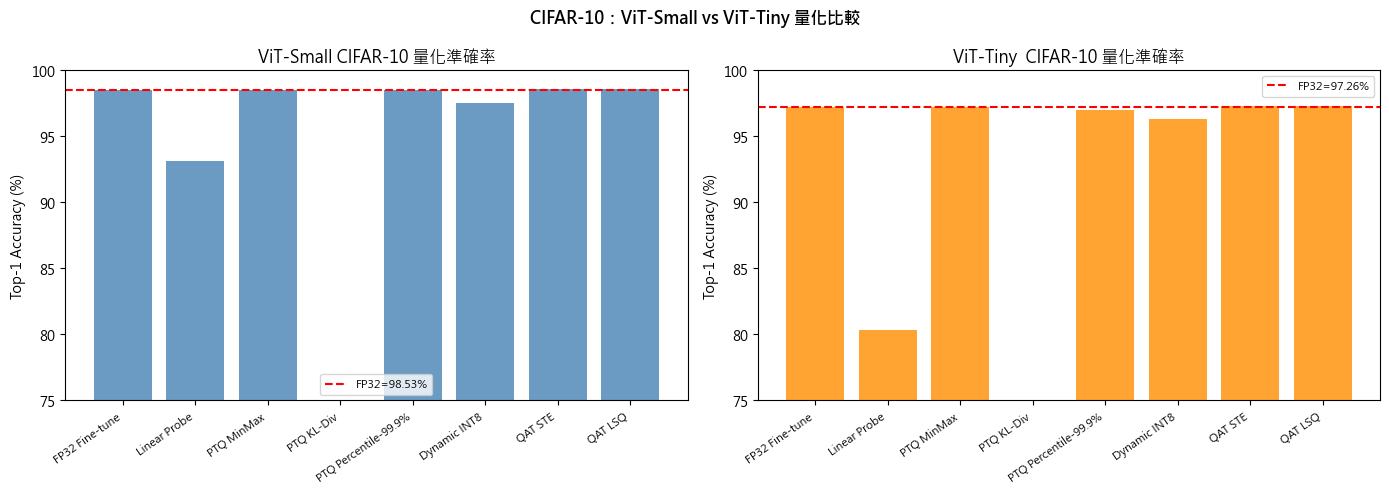

In [24]:
# ═══════════════════════════════════════════
# 【CIFAR-10 總結】完整結果表 + 視覺化
# ═══════════════════════════════════════════
rows = []
for k, v in results.items():
    rows.append({
        "ID": k,
        "模型": v["model"],
        "方法": v["method"],
        "Top-1 (%)": f"{v['acc']:.2f}",
        "CPU P50 (ms)": f"{v['p50_ms']:.1f}" if v["p50_ms"] else "—",
        "參數 (M)": f"{v['params_m']:.1f}",
        "備註": v["note"],
    })

df_all   = pd.DataFrame(rows)
df_small = df_all[df_all["模型"] == "ViT-Small"].reset_index(drop=True)
df_tiny  = df_all[df_all["模型"] == "ViT-Tiny"].reset_index(drop=True)

print("=" * 72)
print("ViT-Small/16 CIFAR-10 結果")
print("=" * 72)
print(df_small[["ID","方法","Top-1 (%)","CPU P50 (ms)","備註"]].to_string(index=False))

print()
print("=" * 72)
print("ViT-Tiny/16 CIFAR-10 結果")
print("=" * 72)
print(df_tiny[["ID","方法","Top-1 (%)","CPU P50 (ms)","備註"]].to_string(index=False))

# ── 橫向比較（回應助教 Q7）
print()
print("=" * 72)
print("選型對比（回應 Q7：為何選 ViT-Small 而非 ViT-Tiny）")
print("=" * 72)
compare = pd.DataFrame([
    {"指標": "FP32 Top-1",
     "ViT-Small": f"{results['EXP-S0']['acc']:.2f}%",
     "ViT-Tiny":  f"{results['EXP-T0']['acc']:.2f}%",
     "差距": f"{results['EXP-S0']['acc']-results['EXP-T0']['acc']:+.2f}pp"},
    {"指標": "QAT STE Top-1",
     "ViT-Small": f"{results['EXP-S6']['acc']:.2f}%",
     "ViT-Tiny":  f"{results['EXP-T6']['acc']:.2f}%",
     "差距": f"{results['EXP-S6']['acc']-results['EXP-T6']['acc']:+.2f}pp"},
    {"指標": "QAT LSQ Top-1",
     "ViT-Small": f"{results['EXP-S7']['acc']:.2f}%",
     "ViT-Tiny":  f"{results['EXP-T7']['acc']:.2f}%",
     "差距": f"{results['EXP-S7']['acc']-results['EXP-T7']['acc']:+.2f}pp"},
    {"指標": "CPU P50 延遲",
     "ViT-Small": f"{results['EXP-S0']['p50_ms']:.1f}ms",
     "ViT-Tiny":  f"{results['EXP-T0']['p50_ms']:.1f}ms",
     "差距": f"Small 慢 {results['EXP-S0']['p50_ms']/results['EXP-T0']['p50_ms']:.1f}×"},
    {"指標": "參數量",
     "ViT-Small": f"{results['EXP-S0']['params_m']:.1f}M",
     "ViT-Tiny":  f"{results['EXP-T0']['params_m']:.1f}M",
     "差距": f"Small 多 {results['EXP-S0']['params_m']/results['EXP-T0']['params_m']:.1f}×"},
])
print(compare.to_string(index=False))

# ── 視覺化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df_m, title, color, base_key) in zip(axes, [
    (df_small, "ViT-Small CIFAR-10 量化準確率", "steelblue", "EXP-S0"),
    (df_tiny,  "ViT-Tiny  CIFAR-10 量化準確率", "darkorange", "EXP-T0"),
]):
    accs = df_m["Top-1 (%)"].astype(float)
    methods = df_m["方法"]
    xs = range(len(methods))
    ax.bar(xs, accs, color=color, alpha=0.8)
    ax.set_xticks(list(xs))
    ax.set_xticklabels(methods, rotation=35, ha="right", fontsize=8)
    ax.set_ylim(75, 100)
    ax.set_ylabel("Top-1 Accuracy (%)")
    ax.set_title(title)
    ax.axhline(y=results[base_key]["acc"], color="red", linestyle="--",
               label=f"FP32={results[base_key]['acc']:.2f}%")
    ax.legend(fontsize=8)

plt.suptitle("CIFAR-10：ViT-Small vs ViT-Tiny 量化比較", fontweight="bold")
plt.tight_layout()
plt.savefig("cifar10_quantization.png", dpi=150, bbox_inches="tight")
plt.show()


---
## ImageNet 驗證集評估（回應助教 Q5）<a id="13"></a>

**助教問題 Q5：** CIFAR-10 解析度低（32×32 upsampled），可能掩蓋 LUT 近似誤差，
建議換更複雜的資料集驗證量化效果。

**本節做法：**
- 使用 ImageNet-1k 預訓練原始模型（1000 類別頭，無 CIFAR-10 fine-tune）
- 在 ImageNet val 子集（5000 張）上比較 FP32 vs PTQ 各方法的準確率下降幅度
- 若 CIFAR-10 誤差被「遮蓋」，ImageNet 上的量化誤差應更明顯

**如何取得 ImageNet val set：**
```
# Hugging Face 下載

```


In [25]:
# ═══════════════════════════════════════════
# 【ImageNet 資料載入】檢查路徑、建立 loader
# ═══════════════════════════════════════════

_inet_ok = os.path.isdir(IMAGENET_VAL_DIR)
if not _inet_ok:
    print(f"[ImageNet] ⚠ 目錄不存在：{IMAGENET_VAL_DIR}")
    print("  請在 Cell 2（全域設定）修改 IMAGENET_VAL_DIR 後重新執行。")
    print("  跳過後續 ImageNet 評估 Cell。")
else:
    print(f"[ImageNet] 目錄確認：{IMAGENET_VAL_DIR}")

    transform_inet = transforms.Compose([
        transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    inet_full = datasets.ImageFolder(IMAGENET_VAL_DIR, transform=transform_inet)
    total = len(inet_full)
    print(f"  ImageNet val 總張數：{total:,}  類別數：{len(inet_full.classes)}")

    # ── 均勻子集：每類取相同數量（四捨五入），合計 IMAGENET_N_SAMPLES 張
    n_cls   = len(inet_full.classes)
    per_cls = max(1, IMAGENET_N_SAMPLES // n_cls)
    cls_cnt = {}
    subset_idx = []
    for idx, (_, label) in enumerate(inet_full.samples):
        cls_cnt[label] = cls_cnt.get(label, 0)
        if cls_cnt[label] < per_cls:
            subset_idx.append(idx)
            cls_cnt[label] += 1

    inet_loader = DataLoader(
        Subset(inet_full, subset_idx),
        batch_size=BATCH_TEST, shuffle=False,
        num_workers=2, pin_memory=True
    )
    print(f"  使用子集：{len(subset_idx):,} 張（每類 ≤{per_cls} 張）")


[ImageNet] 目錄確認：C:\Users\User\Desktop\AOC_Final\炸彈惡魔\提報後重新規劃\IMAGENET_VAL_HF
  ImageNet val 總張數：46,429  類別數：1000
  使用子集：45,451 張（每類 ≤46 張）


In [26]:
# ═══════════════════════════════════════════
# 【ImageNet 評估】FP32 + PTQ 三種方法
# ═══════════════════════════════════════════
# 使用 ImageNet-1k 原始預訓練模型（1000 類別）
# 目的：驗證量化誤差在更複雜資料集上是否更明顯

if not _inet_ok:
    print("ImageNet 路徑未設定，跳過此 Cell。")
else:
    inet_results = {}

    for model_name, timm_id, label in [
        ("ViT-Small", "vit_small_patch16_224.augreg_in21k_ft_in1k", "S"),
        ("ViT-Tiny",  "vit_tiny_patch16_224.augreg_in21k_ft_in1k",  "T"),
    ]:
        print(f"\n{'='*60}")
        print(f"[ImageNet] {model_name}")
        print(f"{'='*60}")

        # 載入 1000 類預訓練模型（不做 CIFAR-10 fine-tune）
        m_fp32 = timm.create_model(timm_id, pretrained=True)
        m_fp32.eval()
        model_info(m_fp32, f"{model_name} pretrained")

        acc_fp32 = evaluate(m_fp32, inet_loader, device=DEVICE)
        inet_results[f"{label}-FP32"] = acc_fp32
        print(f"  FP32 acc={acc_fp32:.2f}%")

        for method, tag in [("minmax","MinMax"), ("kl","KL"), ("percentile","Pct")]:
            m_q = quantize_model_ptq(m_fp32, method=method)
            # PTQ 模型在 CPU 評估
            acc_q = evaluate(m_q, inet_loader, device=torch.device("cpu"))
            drop  = acc_fp32 - acc_q
            inet_results[f"{label}-PTQ-{tag}"] = acc_q
            print(f"  PTQ-{tag}: acc={acc_q:.2f}%  下降={drop:.2f}pp")
            del m_q; torch.cuda.empty_cache()

        del m_fp32; torch.cuda.empty_cache()

    print("\n[ImageNet 評估完成]")



[ImageNet] ViT-Small
[ViT-Small pretrained] 總參數 22.05M  可訓練 22.05M  FP32 大小 84.1 MB
  FP32 acc=74.21%
  [PTQ-MINMAX] 49 層，21,617,664 參數
  PTQ-MinMax: acc=74.22%  下降=-0.01pp
  [PTQ-KL] 49 層，21,617,664 參數
  PTQ-KL: acc=0.27%  下降=73.94pp
  [PTQ-PERCENTILE] 49 層，21,617,664 參數
  PTQ-Pct: acc=74.22%  下降=-0.01pp

[ImageNet] ViT-Tiny
[ViT-Tiny pretrained] 總參數 5.72M  可訓練 5.72M  FP32 大小 21.8 MB
  FP32 acc=45.24%
  [PTQ-MINMAX] 49 層，5,500,416 參數
  PTQ-MinMax: acc=45.46%  下降=-0.22pp
  [PTQ-KL] 49 層，5,500,416 參數
  PTQ-KL: acc=0.20%  下降=45.03pp
  [PTQ-PERCENTILE] 49 層，5,500,416 參數
  PTQ-Pct: acc=45.07%  下降=0.17pp

[ImageNet 評估完成]


In [27]:
# ═══════════════════════════════════════════
# 【Q5 回應】CIFAR-10 vs ImageNet 量化誤差對比
# ═══════════════════════════════════════════
# 若量化誤差在 ImageNet 上明顯大於 CIFAR-10，
# 說明助教 Q5 的擔憂成立，需進一步調整 LUT 精度或校準策略

if not _inet_ok:
    print("ImageNet 路徑未設定，跳過此 Cell。")
else:
    compare_rows = []
    for arch, s_key, t_key in [
        ("ViT-Small", "EXP-S0", "S"),
        ("ViT-Tiny",  "EXP-T0", "T"),
    ]:
        fp32_cifar = results[s_key]["acc"] if arch == "ViT-Small" else results["EXP-T0"]["acc"]
        fp32_inet  = inet_results.get(f"{t_key}-FP32", float("nan"))

        for method, tag in [("MinMax","MinMax"), ("KL","KL"), ("Pct","Pct")]:
            exp_key = f"EXP-{'S' if arch=='ViT-Small' else 'T'}{['MinMax','KL','Pct'].index(method)+2}"
            cifar_q  = results.get(exp_key, {}).get("acc", float("nan"))
            inet_q   = inet_results.get(f"{t_key}-PTQ-{tag}", float("nan"))
            compare_rows.append({
                "模型":          arch,
                "量化方法":       f"PTQ {tag}",
                "CIFAR-10 FP32": f"{fp32_cifar:.2f}%",
                "CIFAR-10 INT8": f"{cifar_q:.2f}%",
                "CIFAR-10 誤差": f"{fp32_cifar - cifar_q:.2f}pp",
                "ImageNet FP32": f"{fp32_inet:.2f}%",
                "ImageNet INT8": f"{inet_q:.2f}%",
                "ImageNet 誤差": f"{fp32_inet - inet_q:.2f}pp",
            })

    df_compare = pd.DataFrame(compare_rows)
    print("=" * 90)
    print("CIFAR-10 vs ImageNet：量化誤差（accuracy drop）對比")
    print("=" * 90)
    print(df_compare.to_string(index=False))

    print()
    print("── 結論 ──")
    for row in compare_rows:
        c_err = float(row["CIFAR-10 誤差"].replace("pp",""))
        i_err = float(row["ImageNet 誤差"].replace("pp",""))
        ratio = i_err / (c_err + 1e-6)
        print(f"  {row['模型']} {row['量化方法']}: "
              f"ImageNet 誤差是 CIFAR-10 的 {ratio:.1f}× "
              f"({'較嚴重' if ratio > 2 else '相近'})")


CIFAR-10 vs ImageNet：量化誤差（accuracy drop）對比
       模型       量化方法 CIFAR-10 FP32 CIFAR-10 INT8 CIFAR-10 誤差 ImageNet FP32 ImageNet INT8 ImageNet 誤差
ViT-Small PTQ MinMax        98.53%        98.49%      0.04pp        74.21%        74.22%     -0.01pp
ViT-Small     PTQ KL        98.53%        12.24%     86.29pp        74.21%         0.27%     73.94pp
ViT-Small    PTQ Pct        98.53%        98.50%      0.03pp        74.21%        74.22%     -0.01pp
 ViT-Tiny PTQ MinMax        97.26%        97.21%      0.05pp        45.24%        45.46%     -0.22pp
 ViT-Tiny     PTQ KL        97.26%        10.16%     87.10pp        45.24%         0.20%     45.03pp
 ViT-Tiny    PTQ Pct        97.26%        97.00%      0.26pp        45.24%        45.07%      0.17pp

── 結論 ──
  ViT-Small PTQ MinMax: ImageNet 誤差是 CIFAR-10 的 -0.2× (相近)
  ViT-Small PTQ KL: ImageNet 誤差是 CIFAR-10 的 0.9× (相近)
  ViT-Small PTQ Pct: ImageNet 誤差是 CIFAR-10 的 -0.3× (相近)
  ViT-Tiny PTQ MinMax: ImageNet 誤差是 CIFAR-10 的 -4.4× (相近)
  ViT-Tiny PT

---
## PYNQ-Z2 硬體資源估算 <a id="14"></a>

14×14 Systolic Array @ 125 MHz，上限：220 DSP / 140 BRAM / 53,200 LUT


In [28]:
# ═══════════════════════════════════════════
# 【PYNQ-Z2 硬體資源估算表】
# ═══════════════════════════════════════════
hw = {
    "資源項目":       ["參數量","FLOPs/image","推論時間@125MHz",
                       "SA DSP（14×14）","PPU DSP","DSP 合計",
                       "BRAM（Ping-Pong+FA+LUT）","LUT（控制+近似）"],
    "ViT-Small":     ["22.1M","~4.24G","~2,100ms","196","~5","~201 (91%)","~80 (57%)","~15,300 (29%)"],
    "ViT-Tiny":      ["5.7M","~1.08G","~528ms","196（共用）","~5","~201 (91%)","~52 (37%)","~12,800 (24%)"],
    "PYNQ-Z2 上限":  ["—","49 GOPS INT8","—","220","220","220","140","53,200"],
}
print(pd.DataFrame(hw).to_string(index=False))

print()
print("選型結論（回應助教 Q7）：")
if "EXP-S0" in results and "EXP-T0" in results:
    gap = results["EXP-S0"]["acc"] - results["EXP-T0"]["acc"]
    print(f"  FP32 準確率差距 = {gap:+.2f}pp（Small - Tiny）")
    if gap > 1.0:
        print("  → ViT-Small 準確率顯著較高，選用 ViT-Small 有充分數據支撐")
    elif gap > 0.3:
        print("  → ViT-Small 略優，FPGA 資源充足時推薦 ViT-Small")
    else:
        print("  → 兩者相近，資源受限時可考慮 ViT-Tiny")
else:
    print("  請先完成 EXP-S0 與 EXP-T0 再執行此 Cell")


                  資源項目     ViT-Small      ViT-Tiny   PYNQ-Z2 上限
                   參數量         22.1M          5.7M            —
           FLOPs/image        ~4.24G        ~1.08G 49 GOPS INT8
           推論時間@125MHz      ~2,100ms        ~528ms            —
         SA DSP（14×14）           196       196（共用）          220
               PPU DSP            ~5            ~5          220
                DSP 合計    ~201 (91%)    ~201 (91%)          220
BRAM（Ping-Pong+FA+LUT）     ~80 (57%)     ~52 (37%)          140
            LUT（控制+近似） ~15,300 (29%) ~12,800 (24%)       53,200

選型結論（回應助教 Q7）：
  FP32 準確率差距 = +1.27pp（Small - Tiny）
  → ViT-Small 準確率顯著較高，選用 ViT-Small 有充分數據支撐
